In [1]:
# 데이터 확인하기 2025.11.19
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 원본 데이터 불러오기
df = pd.read_csv("../data/train.csv")


TARGET Value Counts: TARGET
0    73012
1     3008
Name: count, dtype: int64

TARGET 비율: TARGET
0    0.960431
1    0.039569
Name: proportion, dtype: float64


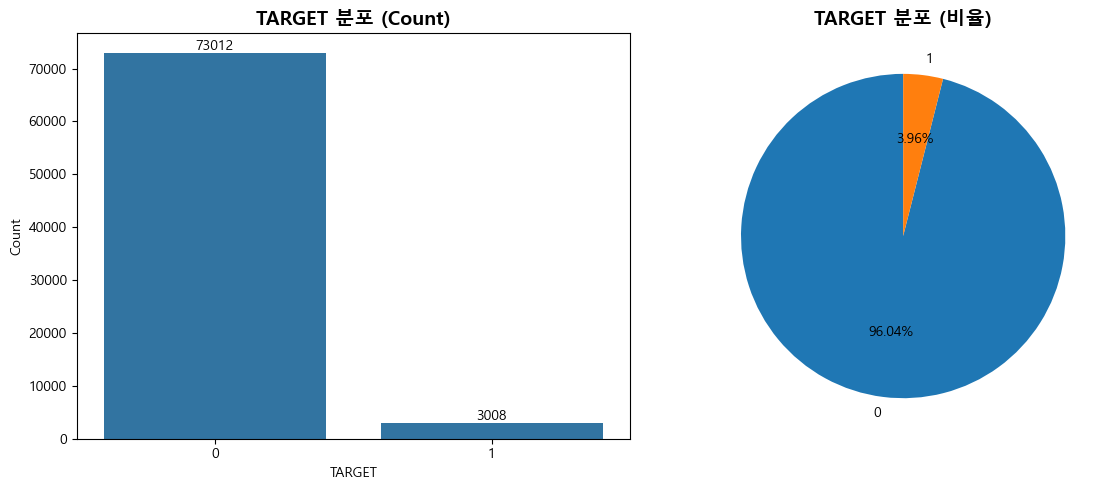

In [3]:
# TARGET value_counts 확인
print(f"\nTARGET Value Counts: {df['TARGET'].value_counts()}")
print(f"\nTARGET 비율: {df['TARGET'].value_counts(normalize=True)}")

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 방법 1: countplot
sns.countplot(x='TARGET', data=df, ax=axes[0])
axes[0].set_title('TARGET 분포 (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('TARGET')
axes[0].set_ylabel('Count')

# 막대 위에 숫자 표시
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# 방법 2: pie chart (비율)
target_counts = df['TARGET'].value_counts()
axes[1].pie(target_counts, labels=target_counts.index, autopct='%1.2f%%', startangle=90)
axes[1].set_title('TARGET 분포 (비율)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [4]:
# 맡은 내 컬럼만 추출
myCols = ['num_op_var40_efect_ult1','num_op_var40_efect_ult3','num_op_var41_comer_ult1','num_op_var41_comer_ult3','num_op_var41_efect_ult1','num_op_var41_efect_ult3','num_op_var39_efect_ult1','num_op_var39_efect_ult3','num_reemb_var13_hace3','num_reemb_var13_ult1','num_reemb_var17_hace3','num_reemb_var17_ult1','num_reemb_var33_hace3','num_reemb_var33_ult1','num_sal_var16_ult1','num_var43_emit_ult1','num_var43_recib_ult1','num_trasp_var11_ult1','num_trasp_var17_in_hace3','num_trasp_var17_in_ult1','num_trasp_var17_out_hace3','num_trasp_var17_out_ult1','num_trasp_var33_in_hace3','num_trasp_var33_in_ult1','num_trasp_var33_out_hace3','num_trasp_var33_out_ult1','num_venta_var44_hace3','num_venta_var44_ult1','num_var45_hace2','num_var45_hace3','num_var45_ult1','num_var45_ult3','saldo_var2_ult1','saldo_medio_var5_hace2','saldo_medio_var5_hace3','saldo_medio_var5_ult1','saldo_medio_var5_ult3','saldo_medio_var8_hace2','saldo_medio_var8_hace3','saldo_medio_var8_ult1','saldo_medio_var8_ult3','saldo_medio_var12_hace2','saldo_medio_var12_hace3','saldo_medio_var12_ult1','saldo_medio_var12_ult3','saldo_medio_var13_corto_hace2','saldo_medio_var13_corto_hace3','saldo_medio_var13_corto_ult1','saldo_medio_var13_corto_ult3','saldo_medio_var13_largo_hace2','saldo_medio_var13_largo_hace3','saldo_medio_var13_largo_ult1','saldo_medio_var13_largo_ult3','saldo_medio_var13_medio_hace2','saldo_medio_var13_medio_hace3','saldo_medio_var13_medio_ult1','saldo_medio_var13_medio_ult3','saldo_medio_var17_hace2','saldo_medio_var17_hace3','saldo_medio_var17_ult1','saldo_medio_var17_ult3','saldo_medio_var29_hace2','saldo_medio_var29_hace3','saldo_medio_var29_ult1','saldo_medio_var29_ult3','saldo_medio_var33_hace2','saldo_medio_var33_hace3','saldo_medio_var33_ult1','saldo_medio_var33_ult3','saldo_medio_var44_hace2','saldo_medio_var44_hace3','saldo_medio_var44_ult1','saldo_medio_var44_ult3','var38']

allCols = df.columns[1:-1].to_list() # allCols

In [5]:
# 방법 2: 요약 정보 (DataFrame으로)
print(f'\n{"="*102}')
print("전체 요약".center(102))
print("="*102)

summary_data = []
for col in myCols:
    if col in df.columns:
        zero_count = (df[col] == 0).sum()
        mode_freq = df[col].value_counts().iloc[0] if len(df[col]) > 0 else 0
        
        summary_data.append({
            'ColumnName': col,  # 컬럼명
            'na_Sum': df[col].isna().sum(),  # 결측치_개수
            'nUnique': df[col].nunique(),  # 고유값_개수
            'mode': df[col].mode()[0] if len(df[col].mode()) > 0 else None,  # 최빈값
            'modeFreq': mode_freq,  # 최빈값_빈도
            'modeFreqRate': f"{(mode_freq / len(df) * 100):.2f}%",  # 최빈값_빈도_비율
            'zero_count': zero_count,  # 0값_개수
            'zero_count_rate': f"{(zero_count / len(df) * 100):.2f}%"  # 0값_비율
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


                                                전체 요약                                                 
                   ColumnName  na_Sum  nUnique          mode  modeFreq modeFreqRate  zero_count zero_count_rate
      num_op_var40_efect_ult1       0        7      0.000000     75982       99.95%       75982          99.95%
      num_op_var40_efect_ult3       0        9      0.000000     75975       99.94%       75975          99.94%
      num_op_var41_comer_ult1       0       60      0.000000     66226       87.12%       66226          87.12%
      num_op_var41_comer_ult3       0       88      0.000000     64480       84.82%       64480          84.82%
      num_op_var41_efect_ult1       0       25      0.000000     69336       91.21%       69336          91.21%
      num_op_var41_efect_ult3       0       40      0.000000     67372       88.62%       67372          88.62%
      num_op_var39_efect_ult1       0       26      0.000000     69325       91.19%       69325          91.19%


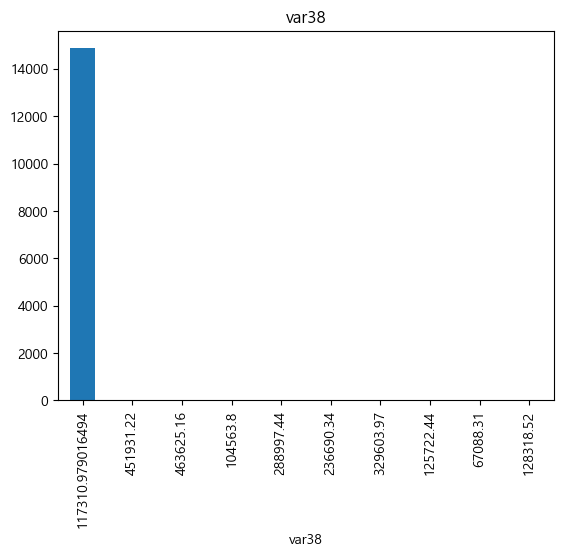

In [6]:
# 특정 컬럼 시각화
df['var38'].value_counts().head(10).plot(kind='bar')
plt.title('var38')
plt.show()


                               컬럼별 값 분포 시각화 (5개씩)                               


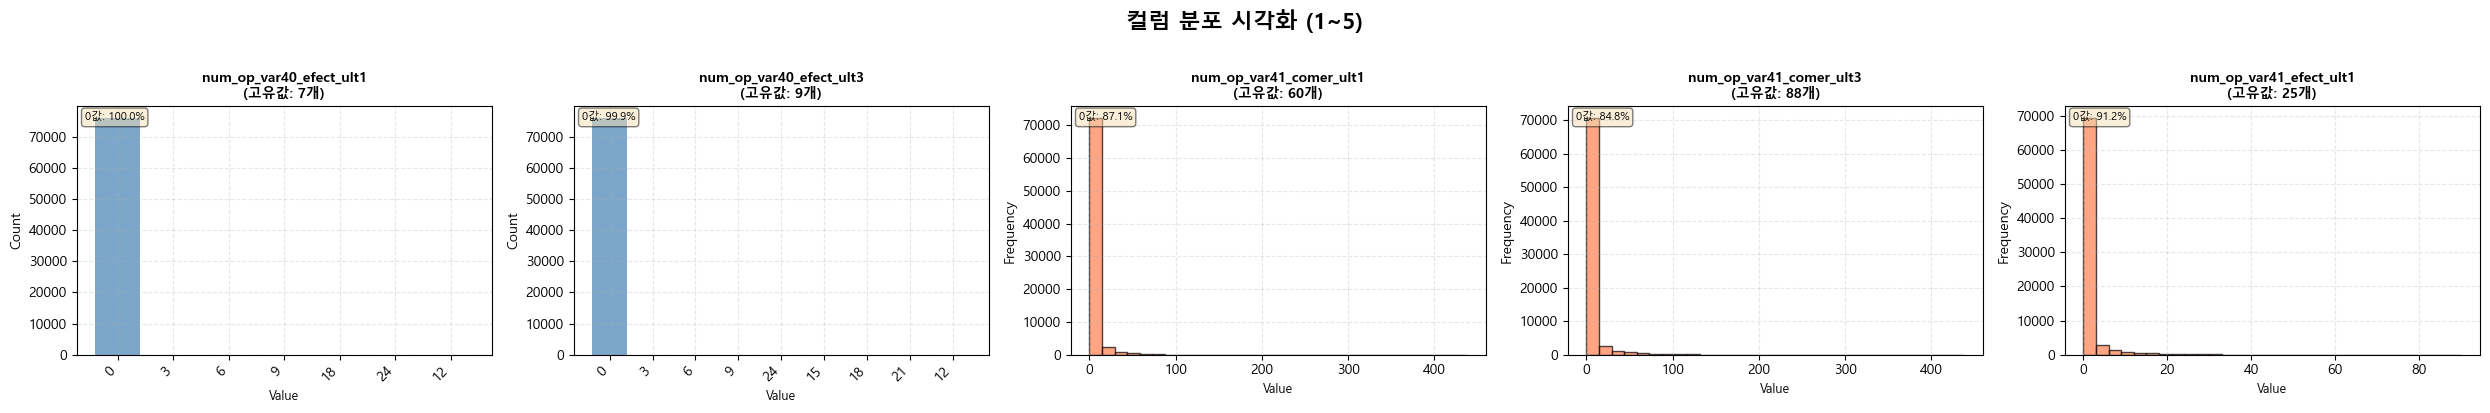


그룹 1 완료: ['num_op_var40_efect_ult1', 'num_op_var40_efect_ult3', 'num_op_var41_comer_ult1', 'num_op_var41_comer_ult3', 'num_op_var41_efect_ult1']
--------------------------------------------------------------------------------


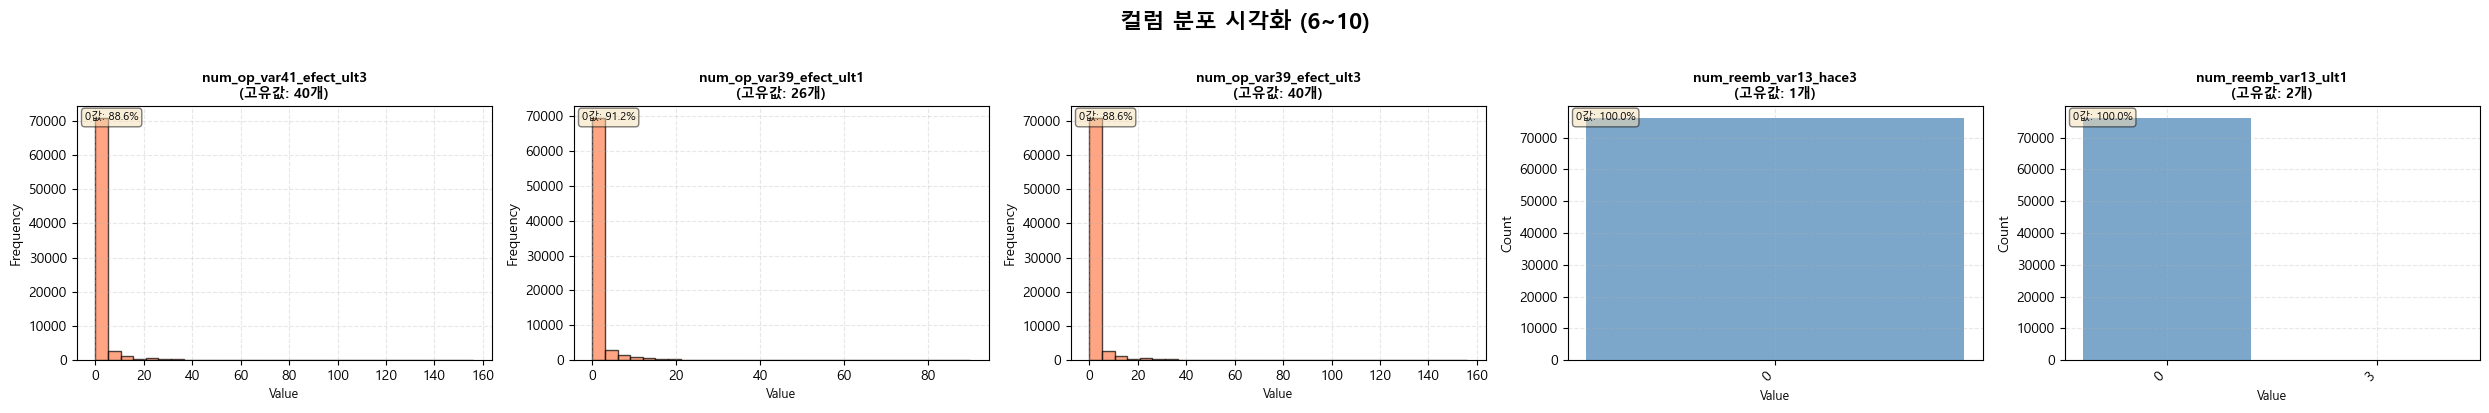


그룹 2 완료: ['num_op_var41_efect_ult3', 'num_op_var39_efect_ult1', 'num_op_var39_efect_ult3', 'num_reemb_var13_hace3', 'num_reemb_var13_ult1']
--------------------------------------------------------------------------------


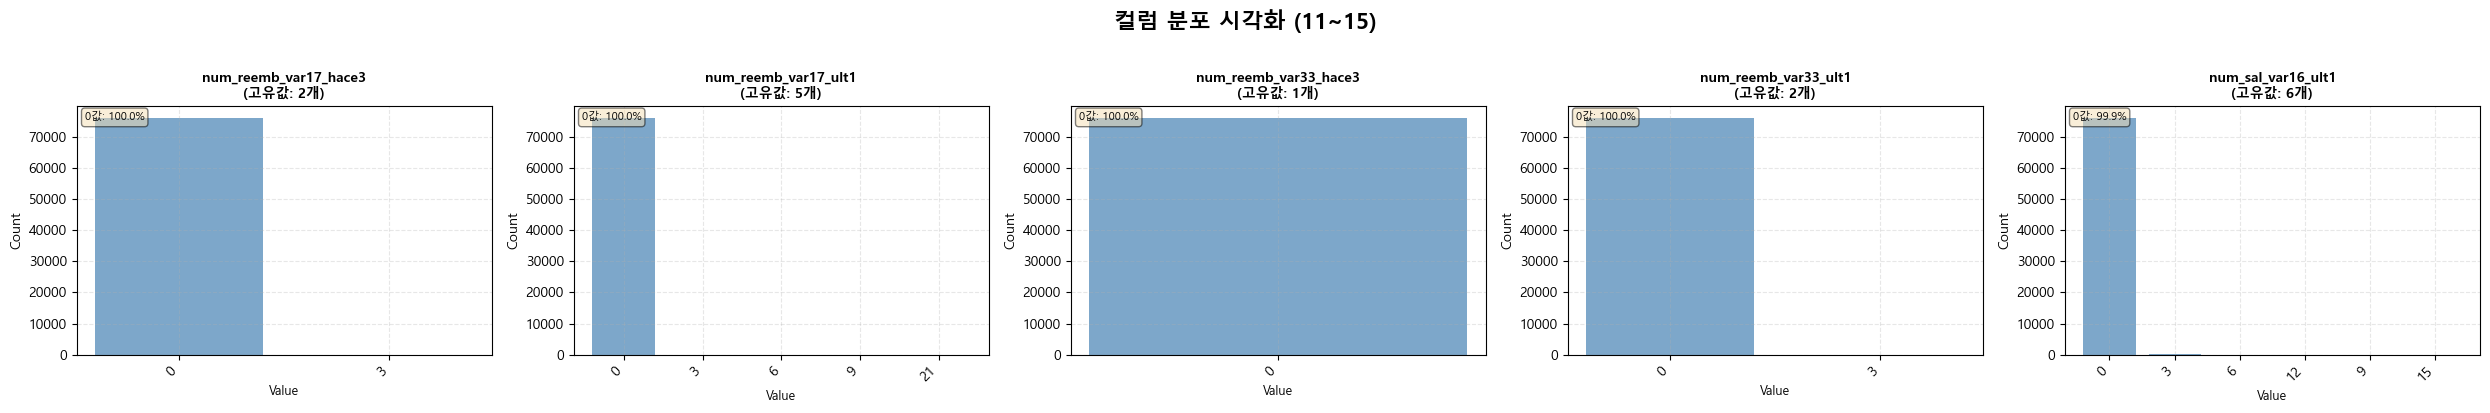


그룹 3 완료: ['num_reemb_var17_hace3', 'num_reemb_var17_ult1', 'num_reemb_var33_hace3', 'num_reemb_var33_ult1', 'num_sal_var16_ult1']
--------------------------------------------------------------------------------


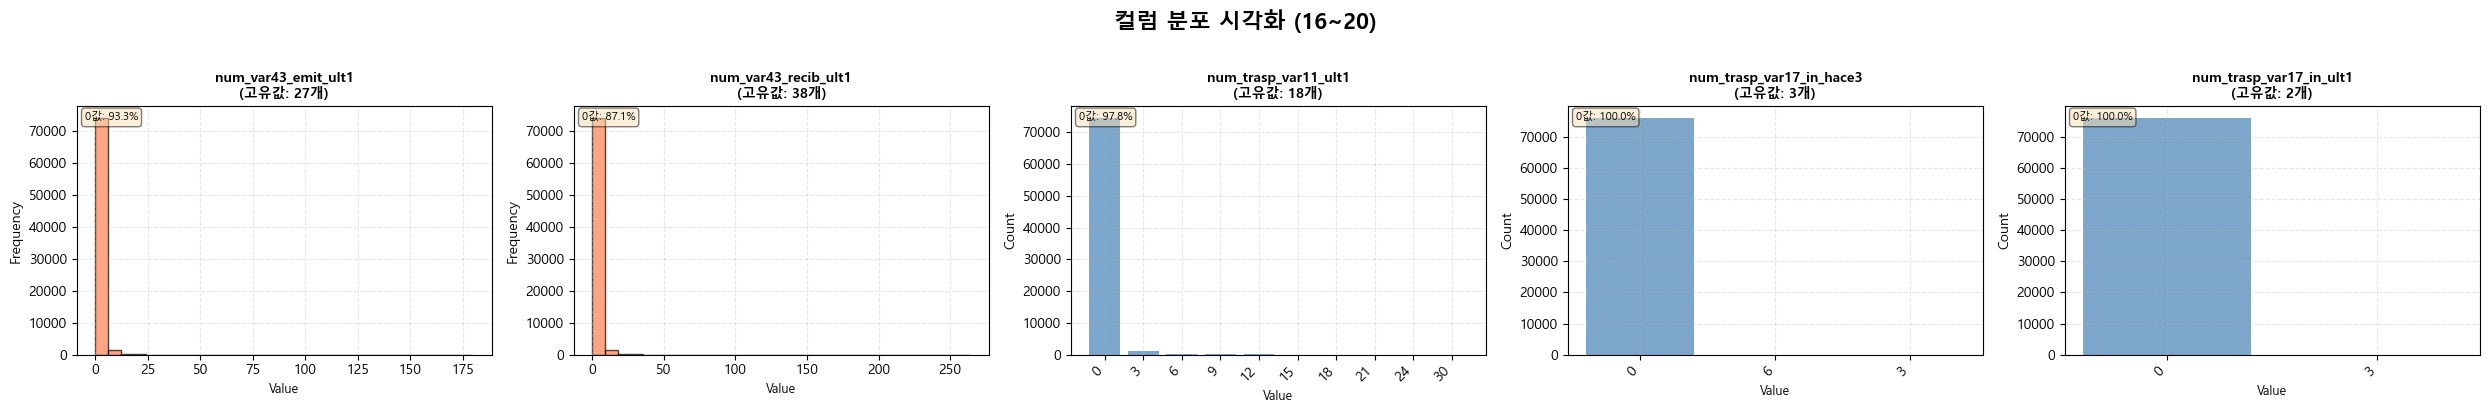


그룹 4 완료: ['num_var43_emit_ult1', 'num_var43_recib_ult1', 'num_trasp_var11_ult1', 'num_trasp_var17_in_hace3', 'num_trasp_var17_in_ult1']
--------------------------------------------------------------------------------


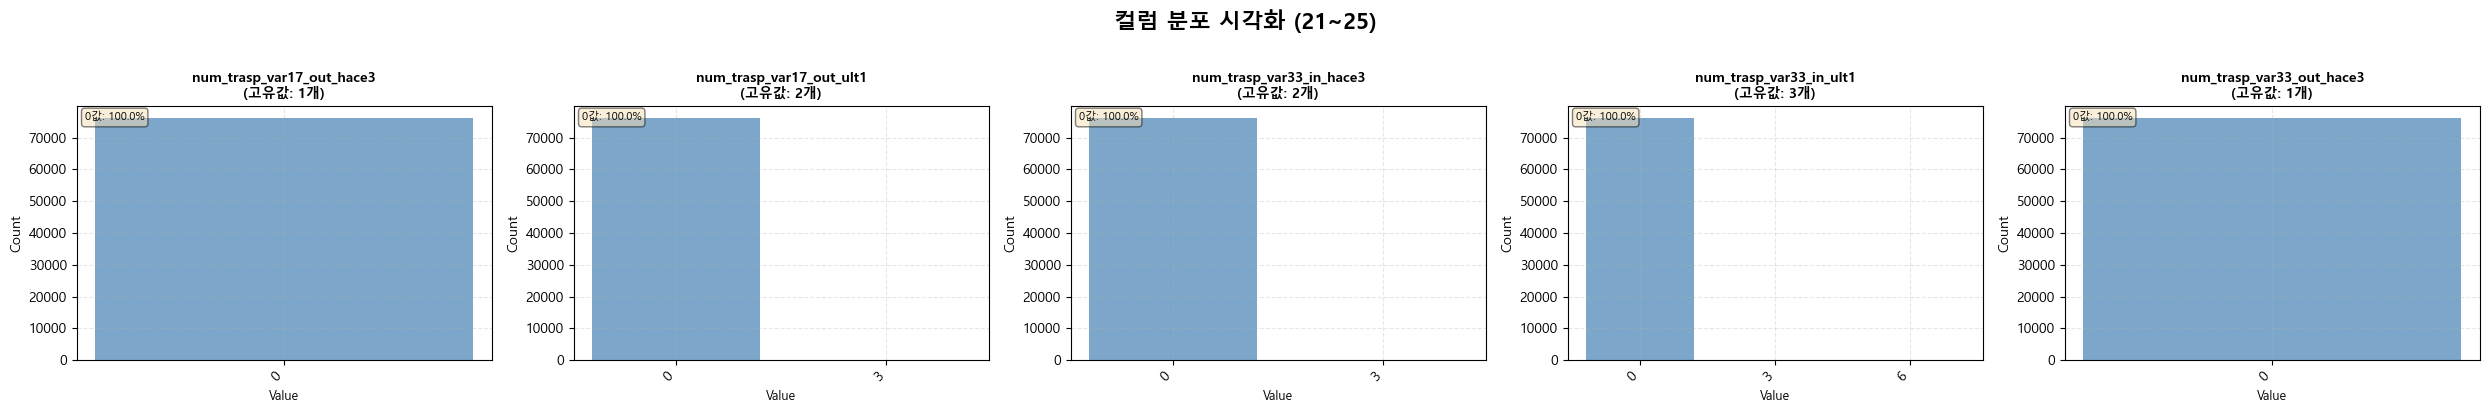


그룹 5 완료: ['num_trasp_var17_out_hace3', 'num_trasp_var17_out_ult1', 'num_trasp_var33_in_hace3', 'num_trasp_var33_in_ult1', 'num_trasp_var33_out_hace3']
--------------------------------------------------------------------------------


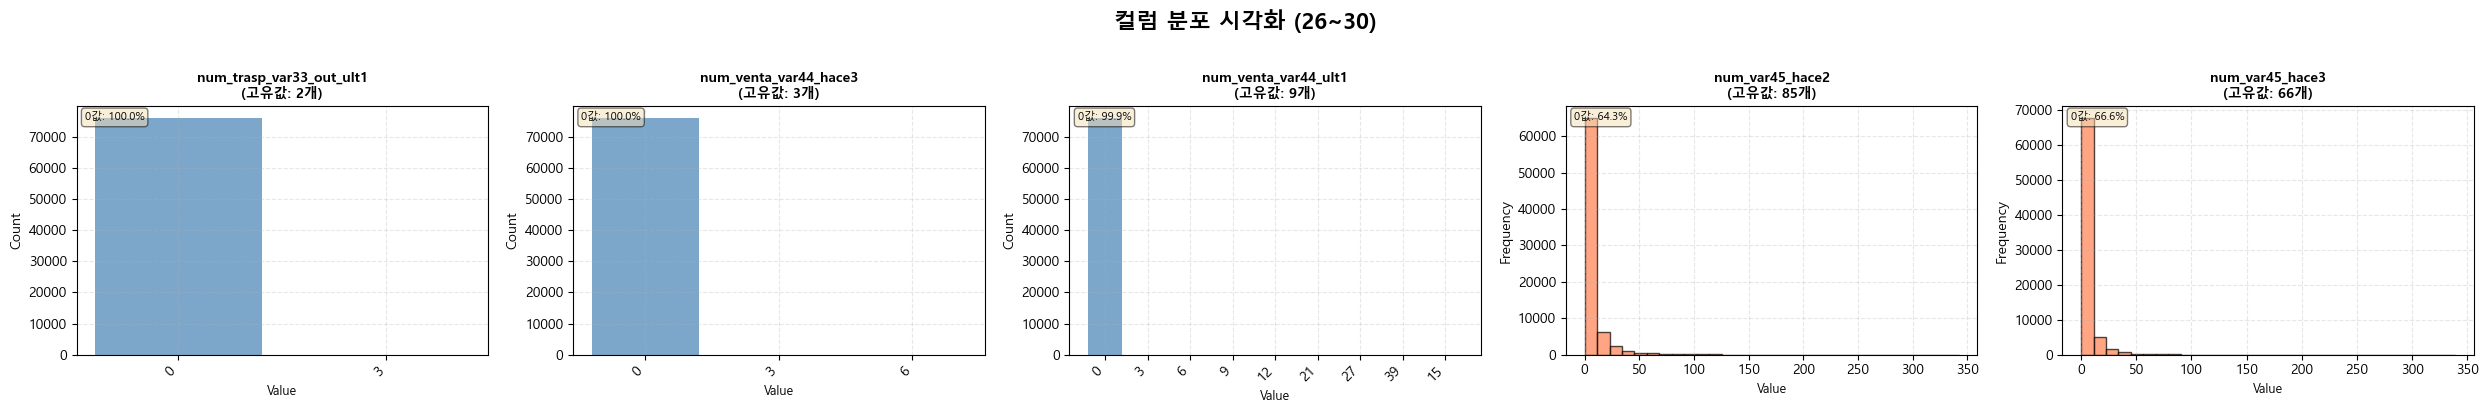


그룹 6 완료: ['num_trasp_var33_out_ult1', 'num_venta_var44_hace3', 'num_venta_var44_ult1', 'num_var45_hace2', 'num_var45_hace3']
--------------------------------------------------------------------------------


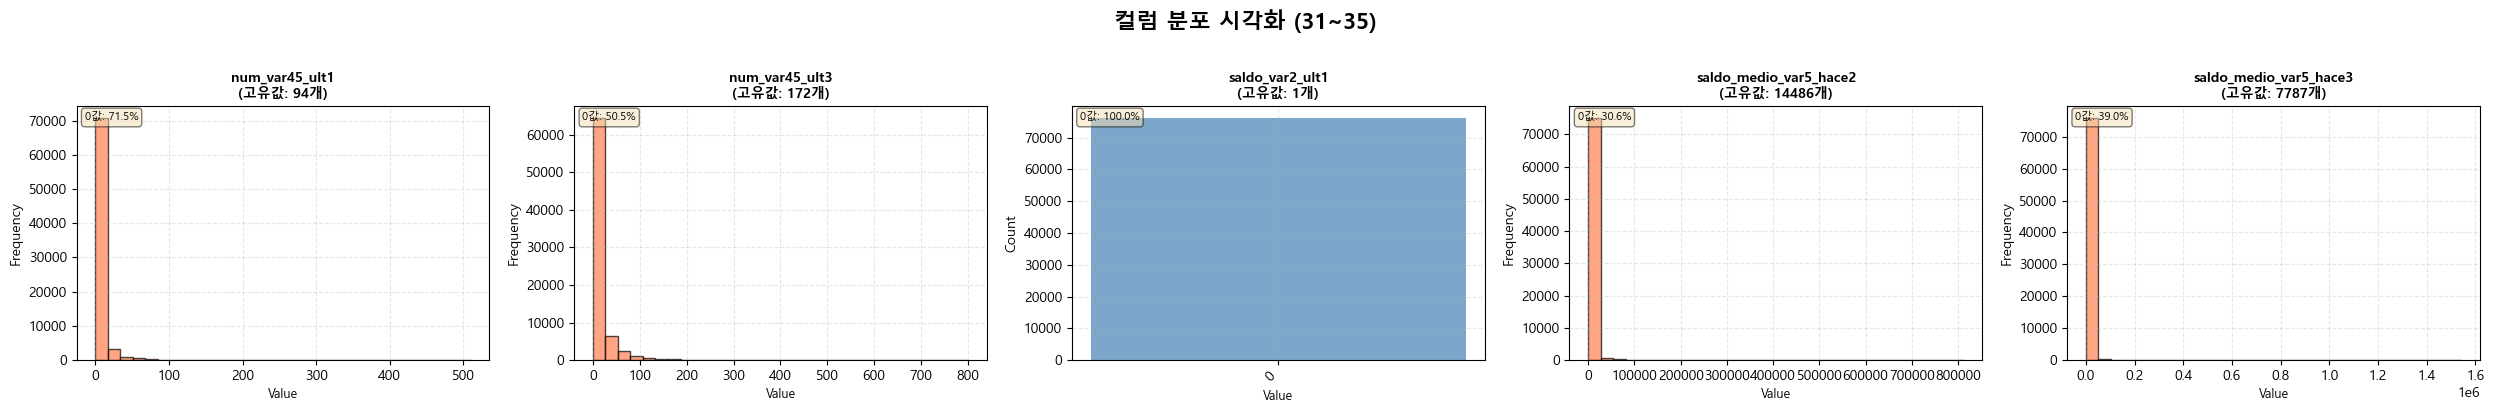


그룹 7 완료: ['num_var45_ult1', 'num_var45_ult3', 'saldo_var2_ult1', 'saldo_medio_var5_hace2', 'saldo_medio_var5_hace3']
--------------------------------------------------------------------------------


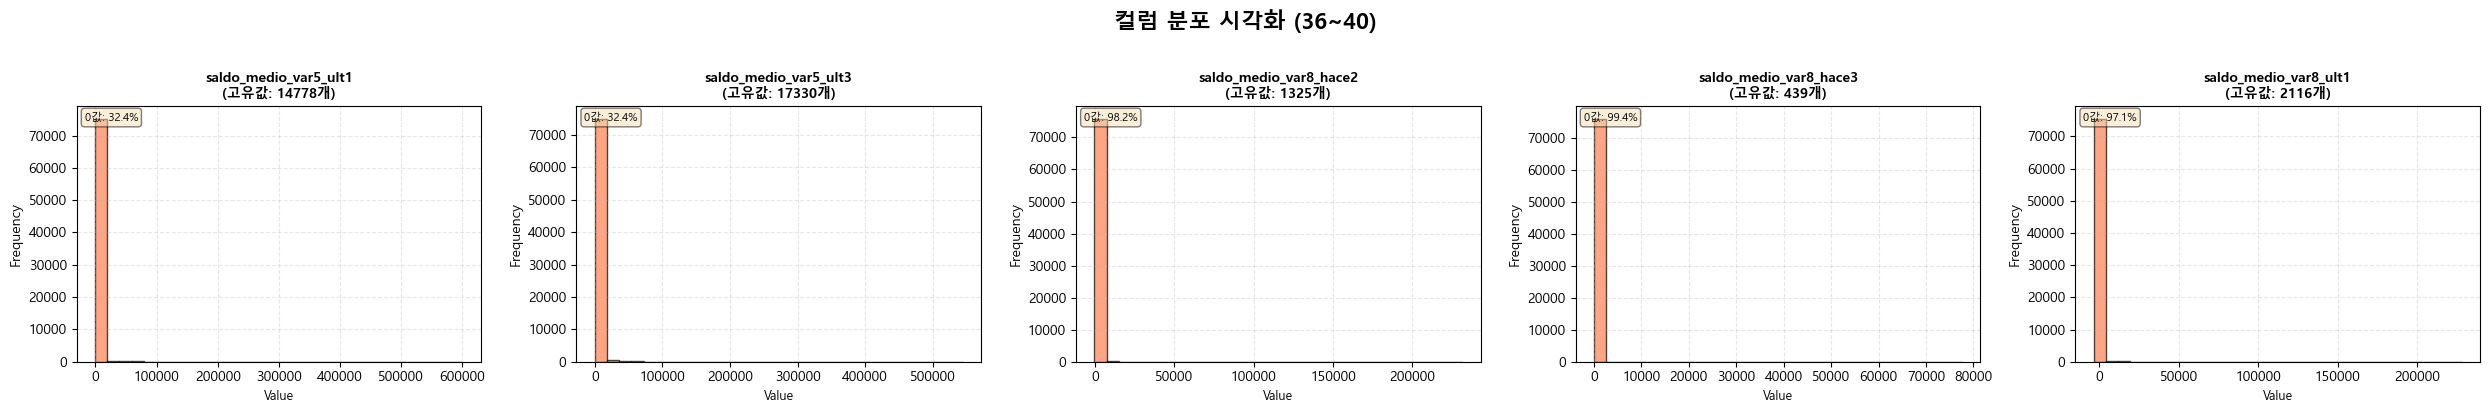


그룹 8 완료: ['saldo_medio_var5_ult1', 'saldo_medio_var5_ult3', 'saldo_medio_var8_hace2', 'saldo_medio_var8_hace3', 'saldo_medio_var8_ult1']
--------------------------------------------------------------------------------


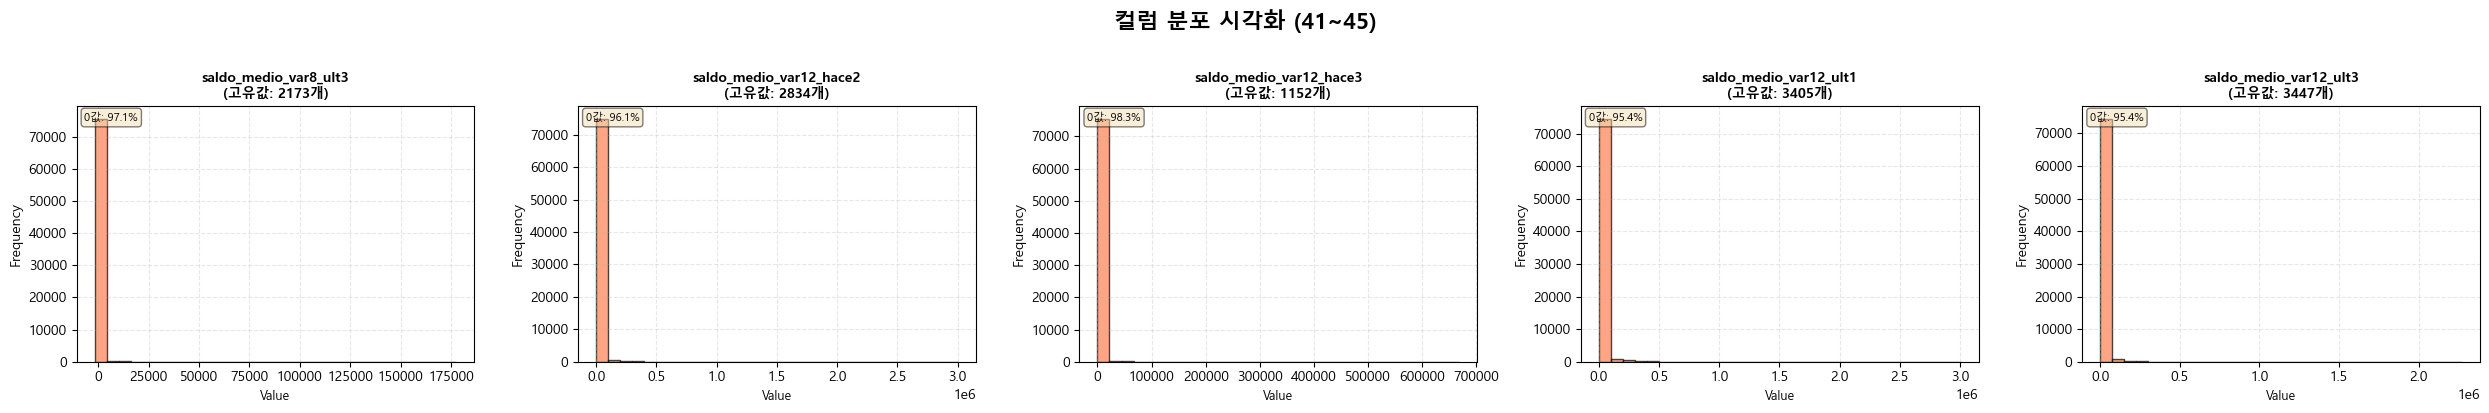


그룹 9 완료: ['saldo_medio_var8_ult3', 'saldo_medio_var12_hace2', 'saldo_medio_var12_hace3', 'saldo_medio_var12_ult1', 'saldo_medio_var12_ult3']
--------------------------------------------------------------------------------


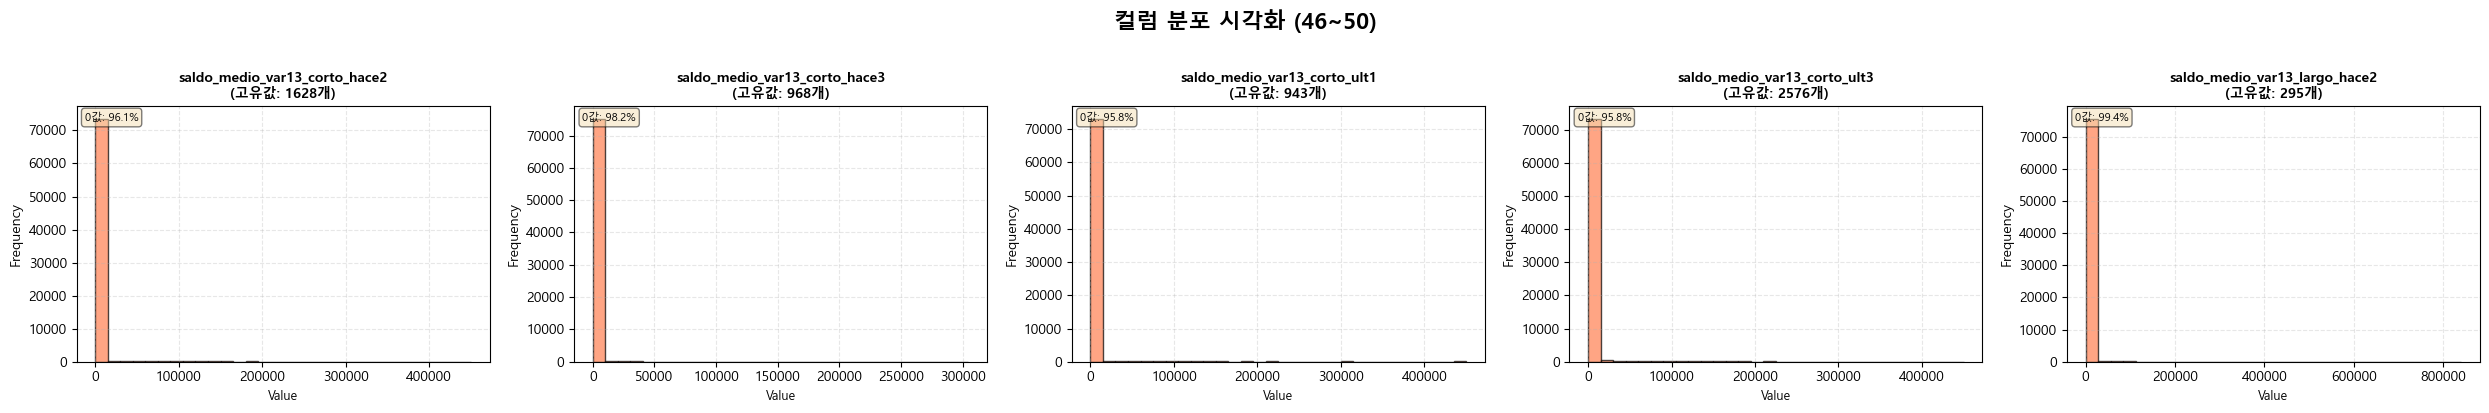


그룹 10 완료: ['saldo_medio_var13_corto_hace2', 'saldo_medio_var13_corto_hace3', 'saldo_medio_var13_corto_ult1', 'saldo_medio_var13_corto_ult3', 'saldo_medio_var13_largo_hace2']
--------------------------------------------------------------------------------


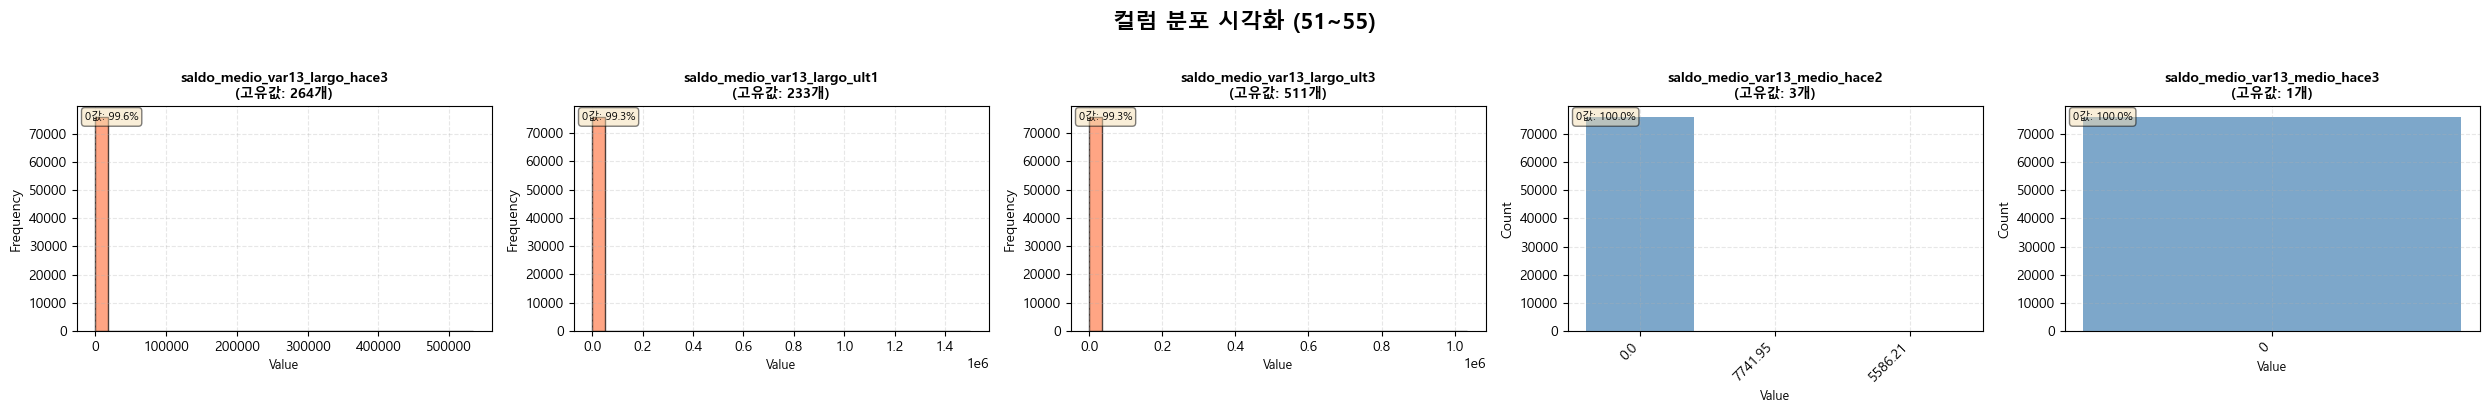


그룹 11 완료: ['saldo_medio_var13_largo_hace3', 'saldo_medio_var13_largo_ult1', 'saldo_medio_var13_largo_ult3', 'saldo_medio_var13_medio_hace2', 'saldo_medio_var13_medio_hace3']
--------------------------------------------------------------------------------


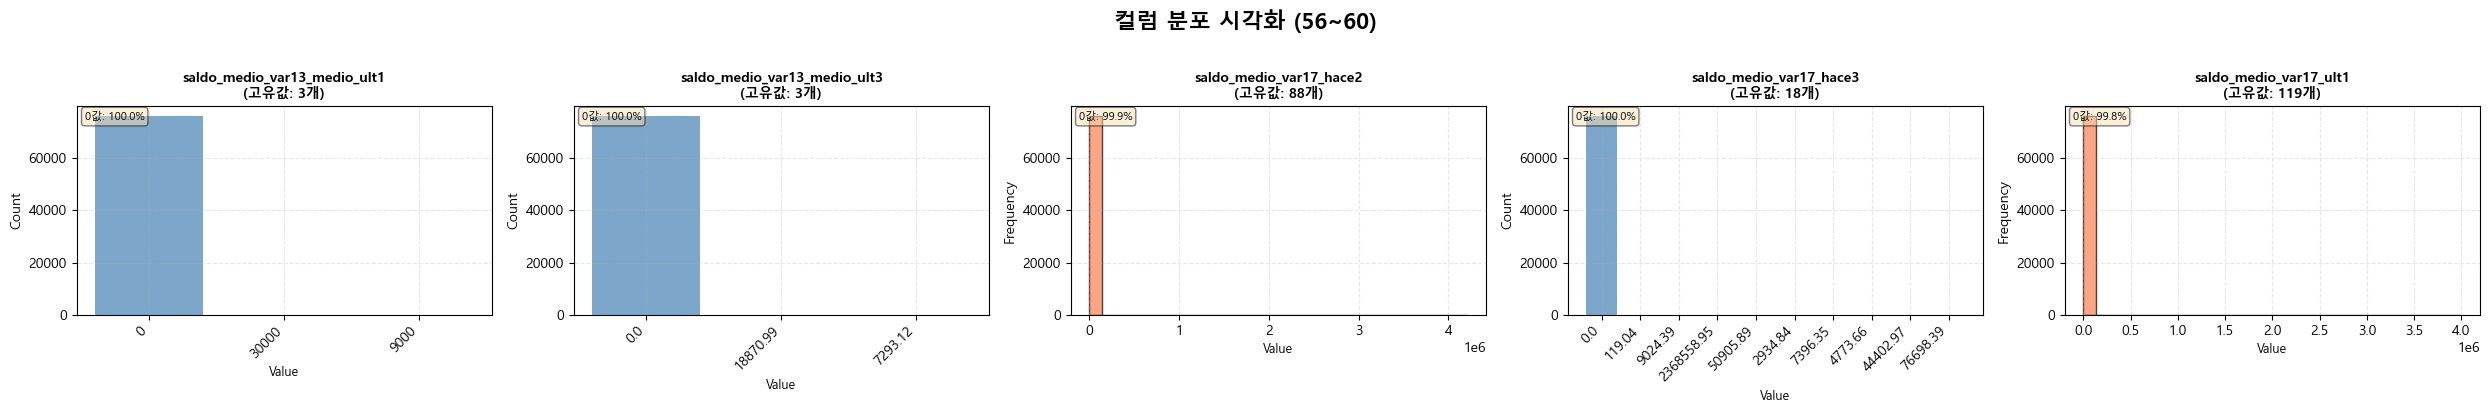


그룹 12 완료: ['saldo_medio_var13_medio_ult1', 'saldo_medio_var13_medio_ult3', 'saldo_medio_var17_hace2', 'saldo_medio_var17_hace3', 'saldo_medio_var17_ult1']
--------------------------------------------------------------------------------


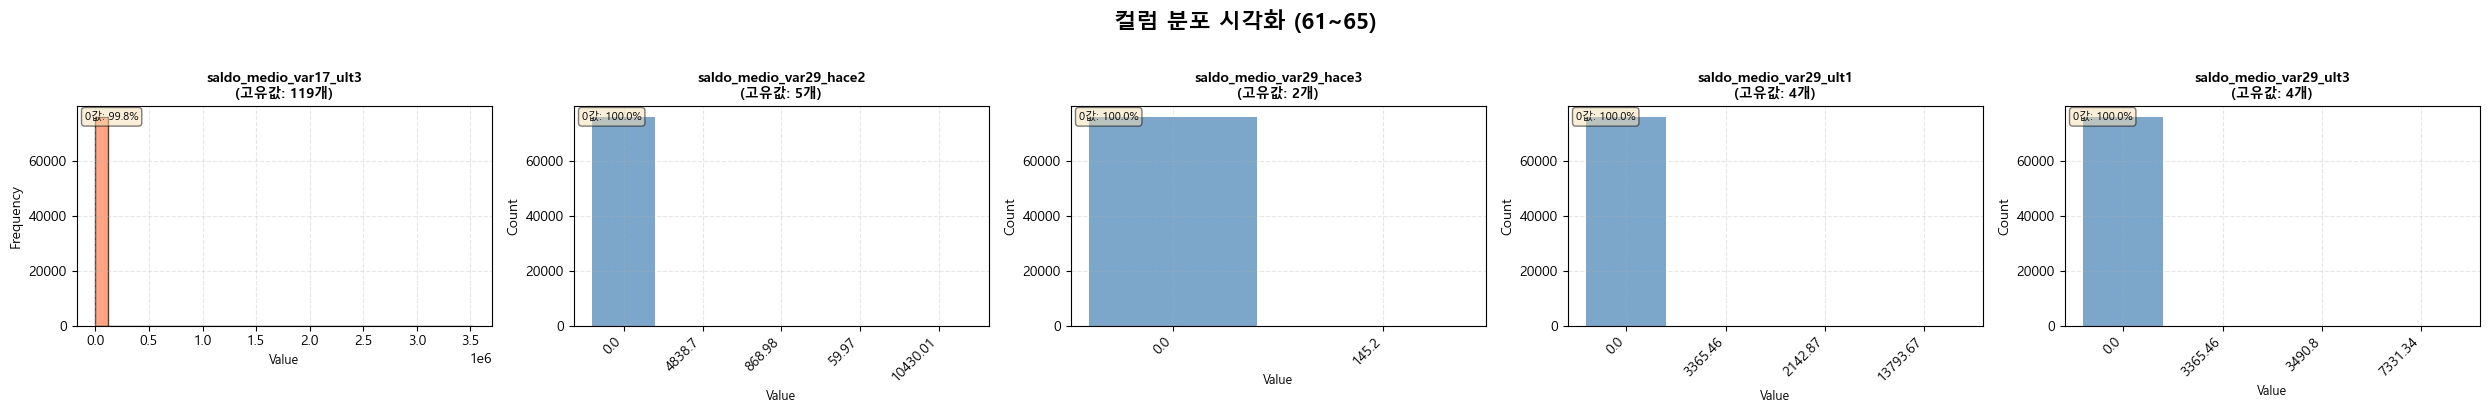


그룹 13 완료: ['saldo_medio_var17_ult3', 'saldo_medio_var29_hace2', 'saldo_medio_var29_hace3', 'saldo_medio_var29_ult1', 'saldo_medio_var29_ult3']
--------------------------------------------------------------------------------


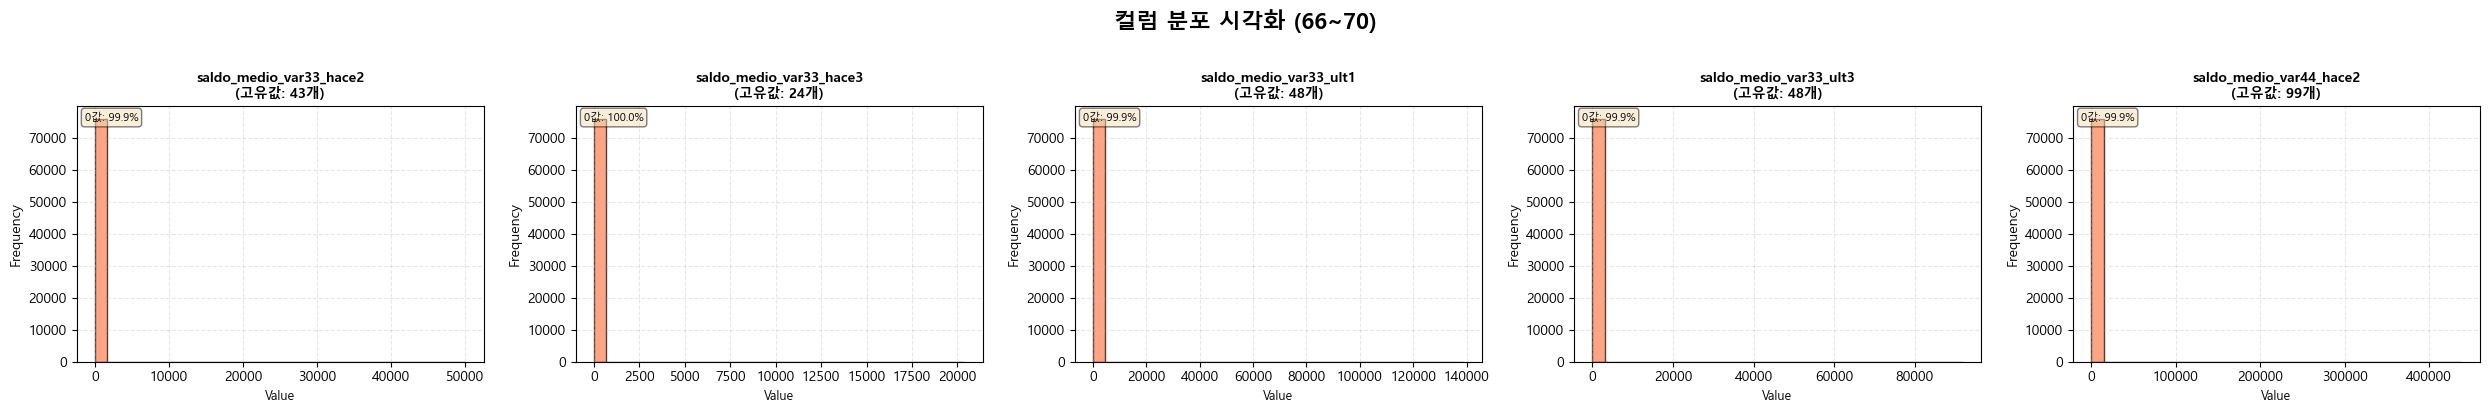


그룹 14 완료: ['saldo_medio_var33_hace2', 'saldo_medio_var33_hace3', 'saldo_medio_var33_ult1', 'saldo_medio_var33_ult3', 'saldo_medio_var44_hace2']
--------------------------------------------------------------------------------


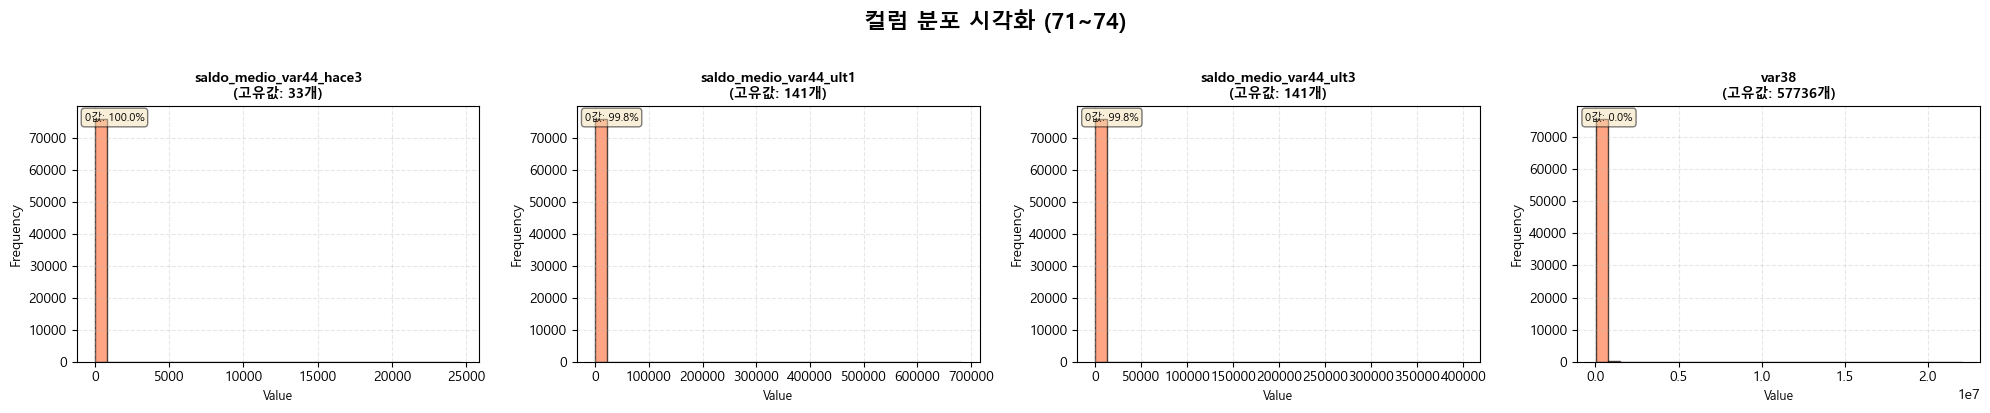


그룹 15 완료: ['saldo_medio_var44_hace3', 'saldo_medio_var44_ult1', 'saldo_medio_var44_ult3', 'var38']
--------------------------------------------------------------------------------


In [7]:
# 5개씩 컬럼 시각화
print(f"\n{'='*80}")
print(f"{'컬럼별 값 분포 시각화 (5개씩)':^80}")
print(f"{'='*80}")

# myCols를 5개씩 나누기
cols_per_plot = 5
num_plots = int(np.ceil(len(myCols) / cols_per_plot))

for plot_idx in range(num_plots):
    # 현재 그룹의 컬럼들
    start_idx = plot_idx * cols_per_plot
    end_idx = min((plot_idx + 1) * cols_per_plot, len(myCols))
    current_cols = myCols[start_idx:end_idx]
    
    # 실제 존재하는 컬럼만 필터링
    existing_cols = [col for col in current_cols if col in df.columns]
    
    if not existing_cols:
        continue
    
    # 서브플롯 생성
    fig, axes = plt.subplots(1, len(existing_cols), figsize=(5*len(existing_cols), 4))
    
    # axes가 단일 객체인 경우 리스트로 변환
    if len(existing_cols) == 1:
        axes = [axes]
    
    fig.suptitle(f'컬럼 분포 시각화 ({start_idx+1}~{start_idx+len(existing_cols)})', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    # 각 컬럼별 히스토그램
    for idx, col in enumerate(existing_cols):
        ax = axes[idx]
        
        # 고유값이 너무 많으면 히스토그램, 적으면 countplot
        n_unique = df[col].nunique()
        
        if n_unique <= 20:  # 고유값이 20개 이하면 countplot
            value_counts = df[col].value_counts().head(10)
            ax.bar(range(len(value_counts)), value_counts.values, color='steelblue', alpha=0.7)
            ax.set_xticks(range(len(value_counts)))
            ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
            ax.set_ylabel('Count', fontsize=10)
        else:  # 고유값이 많으면 히스토그램
            df[col].hist(bins=30, ax=ax, color='coral', alpha=0.7, edgecolor='black')
            ax.set_ylabel('Frequency', fontsize=10)
        
        ax.set_title(f'{col}\n(고유값: {n_unique}개)', fontsize=10, fontweight='bold')
        ax.set_xlabel('Value', fontsize=9)
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # 0값 비율 표시
        zero_rate = (df[col] == 0).sum() / len(df) * 100
        ax.text(0.02, 0.98, f'0값: {zero_rate:.1f}%', 
                transform=ax.transAxes, 
                fontsize=8, 
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    plt.show()
    print(f"\n그룹 {plot_idx+1} 완료: {existing_cols}")
    print(f"{'-'*80}")